<a href="https://colab.research.google.com/github/ProfessorPatrickSlatraigh/CST3512_HD34/blob/main/CST3512_Week03_APIs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **CST3512 - Information and Data Management II**


    


---

#APIs (Application Program Interfaces)    


**Summary explanations of API concepts and sample uses.**

*by Professor Patrick, April 2022, November 2022, April 2023, September 2023.*


In [1]:
import requests

### Country information from the `REST Countries` API (without a key)

*This example prompts the user for a string with a country name, then it uses the REST Countries API to retrieve the population, capital city, and region of the world for the country, if it is found.*

In [2]:
#

def get_country_info(country_name):
    # URL of the REST Countries API
    url = f"https://restcountries.com/v3.1/name/{country_name}"

    try:
        # Send a GET request to the API
        response = requests.get(url)

        # Check if the request was successful (status code 200)
        if response.status_code == 200:
            # Parse the JSON response
            data = response.json()[0]  # Assuming there's only one result

            # Extract and display relevant information
            name = data["name"]["common"]
            capital = data["capital"][0]
            population = data["population"]
            region = data["region"]

            print(f"Country: {name}")
            print(f"Capital: {capital}")
            print(f"Population: {population}")
            print(f"Region: {region}")
        else:
            print("Failed to retrieve data. Check the country name or try again later.")
    except Exception as e:
        print(f"An error occurred: {str(e)}")

if __name__ == "__main__":
    country_name = input("Enter a country name: ")
    get_country_info(country_name)


Enter a country name: Dominican Republic
Country: Dominican Republic
Capital: Santo Domingo
Population: 10771504
Region: Americas


##**1. Web Applications**    

##Housekeeping    

*import libraries needed*   

In [3]:
\# import methods from the urllib module
import urllib.request, urllib.parse, urllib.error

### **Making HTTP Easier With urllib**


**Using urllib in Python**

Since HTTP is so common, we have a library that does all the socket work for us and makes web pages look like a file

Reference: urllib1.py


In [4]:
# this is a simple example which works with a text file at a URL
# notice that the file handle does not process metadata as lines

# import methods from the urllib module
import urllib.request, urllib.parse, urllib.error

# open a file handle with a request to an HTTP resource URL
fhand = urllib.request.urlopen('http://data.pr4e.org/romeo.txt')

# process the lines in the file
for line in fhand:
    print(line.decode().strip())


But soft what light through yonder window breaks
It is the east and Juliet is the sun
Arise fair sun and kill the envious moon
Who is already sick and pale with grief


**Using urllib to Bulid a Dictionary of Word Counts**

The file handle opened with **urllib** can be used in a variety of use cases.  The following example opens a text file on the web and uses **urlopen** and a related file handle to process words in lines of text while building a dictionary of word counts.

Reference: urlwords.py


In [5]:
# if the desired urllib methods are not already imported then activate the next line
# import urllib.request, urllib.parse, urllib.error

# open a file handle with a request to an HTTP resource URL (text file)
fhand = urllib.request.urlopen('http://data.pr4e.org/romeo.txt')

# initiate an empty dictionary variable counts
counts = dict()

# process lines in the file handle, splitting out and counting words
for line in fhand:
    words = line.decode().split()
    for word in words:
        counts[word] = counts.get(word, 0) + 1
print(counts)


{'But': 1, 'soft': 1, 'what': 1, 'light': 1, 'through': 1, 'yonder': 1, 'window': 1, 'breaks': 1, 'It': 1, 'is': 3, 'the': 3, 'east': 1, 'and': 3, 'Juliet': 1, 'sun': 2, 'Arise': 1, 'fair': 1, 'kill': 1, 'envious': 1, 'moon': 1, 'Who': 1, 'already': 1, 'sick': 1, 'pale': 1, 'with': 1, 'grief': 1}


**Reading Web Pages**

The file handle opened with urllib can be used to read web pages into a file handle.


Reference: `https://urllib2.py`   


In [6]:
# if the desired urllib methods are not already imported then activate the next line
# import urllib.request, urllib.parse, urllib.error

# open a file handle with a request to an HTTP resource URL (web page)
fhand = urllib.request.urlopen('http://www.dr-chuck.com/page1.htm')

# read the HTML of a web page, line-by-line and decode and strip it
for line in fhand:
    print(line.decode().strip())


<h1>The First Page</h1>
<p>
If you like, you can switch to the
<a href="http://www.dr-chuck.com/page2.htm">
Second Page</a>.
</p>


In [7]:
fhand.close()

####Using 'regex' with `urlib` Results    

**This notebook section requires importing the regex `re` library**   

In [8]:
import re

**Decode `urlib` result into a text string**    

In [9]:
# open a file handle with a request to an HTTP resource URL (web page)
fhand = urllib.request.urlopen('http://www.dr-chuck.com/page1.htm')

text = ''

for line in fhand:
    text = text + (line.decode().strip())
    # text = text + (line.decode().strip()) +'\n'

In [10]:
print(text)

<h1>The First Page</h1><p>If you like, you can switch to the<a href="http://www.dr-chuck.com/page2.htm">Second Page</a>.</p>


**Search the `text` string for `HTML` tags**    

In [11]:
# use a regex search pattern to find a tag and its content
search_for = r"<([\w]+).*>(.*?)<\/\1>"

matches = re.findall(search_for, text)

In [12]:
for match in matches:
    print(match)

('h1', 'The First Page')
('p', '.')


**Search the `text` string for an `href` link**    

In [13]:
# use a regex search pattern to find an href= and its link in double quotes
search_for = r'"(.*?)"'

matches = re.findall(search_for, text)

In [14]:
for match in matches:
    print(match)

http://www.dr-chuck.com/page2.htm


*note that the last regex search pattern would not find an `href` link inside single quotes -- for that, the following search would work.*    

In [15]:
# use a regex search pattern to find an href= and its link in single quotes
search_for = r"'(.*?)'"

matches = re.findall(search_for, text)

In [16]:
for match in matches:
    print(match)

In [17]:
fhand.close()

####**Following Links**

The file handle opened with urllib can be used to read web pages into a file handle then the Python code can identify and follow links to read other pages.


Reference: urllib2.py


In [18]:
# if the desired urllib methods are not already imported then activate the next line
# import urllib.request, urllib.parse, urllib.error

# open a file handle with a request to an HTTP resource URL (web page)
fhand = urllib.request.urlopen('http://www.dr-chuck.com/page2.htm')

# read the HTML of a web page, line-by-line and decode and strip it
for line in fhand:
    print(line.decode().strip())


<h1>The Second Page</h1>
<p>
If you like, you can switch back to the
<a href="page1.htm">
First Page</a>.
</p>




---



## **2. Web Scraping and Crawling**


**What is Web Scraping?**

When a program or script pretends to be a browser and retrieves web pages, looks at those web pages, extracts information, and then looks at more web pages
Search engines scrape web pages - we call this “spidering the web” or “web crawling”.

Web scraping, web harvesting, or web data extraction is data scraping used for extracting data from websites. The web scraping software may directly access the World Wide Web using the Hypertext Transfer Protocol or a web browser. While web scraping can be done manually by a software user, the term typically refers to automated processes implemented using a bot or web crawler. It is a form of copying in which specific data is gathered and copied from the web, typically into a central local database or spreadsheet, for later retrieval or analysis.

Web scraping a web page involves fetching it and extracting from it. Fetching is the downloading of a page (which a browser does when a user views a page). Therefore, web crawling is a main component of web scraping, to fetch pages for later processing. Once fetched, then extraction can take place. The content of a page may be parsed, searched, reformatted, its data copied into a spreadsheet or loaded into a database. Web scrapers typically take something out of a page, to make use of it for another purpose somewhere else. An example would be to find and copy names and telephone numbers, or companies and their URLs, or e-mail addresses to a list (contact scraping).

Web scraping is used for:
*   as a component of applications used for:
       - web indexing
       - web mining
       - data mining
*   contact scraping
*   gathering real estate listings
*   online price change monitoring
*   price comparison
*   product review scraping (to watch the competition)
*   research
*   tracking online presence and reputation
*   weather data monitoring
*   web mashup
*   web data integration
*   website change detection

Reference: http://en.wikipedia.org/wiki/Web_scraping


**Why Scrape?**

*   <font color=red>Get your own data back out of some system that has no “export capability”</font> - NOT a good idea    
*   Monitor a site for new information
*   Pull data - particularly social data - who links to who?
*   Spider the web to make a database for a search engine

**What is Web Crawling?**

A Web crawler, sometimes called a spider or spiderbot and often shortened to crawler, is an Internet bot that systematically browses the World Wide Web, typically operated by search engines for the purpose of Web indexing (web spidering).[1]

Web search engines and some other websites use Web crawling or spidering software to update their web content or indices of other sites' web content. Web crawlers copy pages for processing by a search engine, which indexes the downloaded pages so that users can search more efficiently.

Crawlers consume resources on visited systems and often visit sites unprompted. Issues of schedule, load, and "politeness" come into play when large collections of pages are accessed. Mechanisms exist for public sites not wishing to be crawled to make this known to the crawling agent. For example, including a robots.txt file can request bots to index only parts of a website, or nothing at all.

Reference: http://en.wikipedia.org/wiki/Web_crawler


**Scraping Web Pages**

There is some controversy about web page scraping and some sites are a bit snippy about it.
*   Republishing copyrighted information is not allowed
*   Violating terms of service is not allowed



---

### **Beautiful Soup**

**The Easy Way - Beautiful Soup**

You could do string searches the hard way

Or use the free software library called BeautifulSoup from www.crummy.com



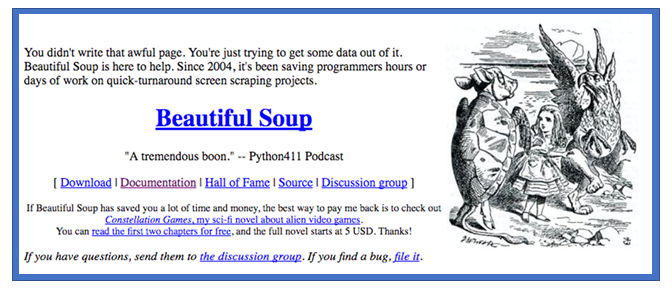

**BeautifulSoup Installation**

Installation of Beautiful Soup may work differently in different environments.

As BeautifulSoup is not a standard python library, you need to install it first. Install the BeautifulSoup 4 library (also known as **BS4**), which is the latest one.  If you are using a Colab environment, you will not need to install BeautifulSoup, just import it as the module **bs4**.

Reference: `https://urllinks.py`  



In [19]:
# To run this, you can install BeautifulSoup
# https://pypi.python.org/pypi/beautifulsoup4

# Or download the file
# http://www.py4e.com/code3/bs4.zip
# and unzip it in the same directory as this file

import urllib.request, urllib.parse, urllib.error
from bs4 import BeautifulSoup


**BeautifulSoup Simple Exercise**

Reference: https://urllinks.py

Enter the following when prompted by the next snippet of code
```    

1.   http://www.dr-chuck.com/page1.htm
```    

The code will open a handle to  the web page, then use BeautifulSoup to parse the content of the web page's HTML which will be loaded into a smart object in the variable soup.  Anchor tags (<a /a> in the soup object are assigned as elements in the list variable tags.  Finally, a for loop processes the each tag in the tags list (which was derived from the soup object) and prints them.  As there is only anchor tag on the web page the program prints the following:
```    

2.   http://www.dr-chuck.com/page2.htm
````    



In [20]:
# if the desired urllib methods are not already imported then activate the next line
# import urllib.request, urllib.parse, urllib.error

# import the class BeautifulSoup from the bs4 module
from bs4 import BeautifulSoup

# prompt the user for a URL to open and load with BeautifulSoup
url = ""
url = input('Enter a URL to scrape: ')
print('Processing BS4 for the link:', url)

if url != "":
    try:
        # open a file handle `html` with the .urlopen() method
        html = urllib.request.urlopen(url).read()
        # parse the html file contents into a BeautifulSoup object named `soup`
        soup = BeautifulSoup(html, 'html.parser')

        # Retrieve all of the anchor tags in the object soup as a list tags
        tags = soup('a')

        # iterate through the list tags and print each anchor tag
        for tag in tags:
            print("Links found: \n", tag.get('href', None))
    except:
        print("\nNot able to open web page: ", url)
else:
    print("\nNothing to process.  Thank you.")


Enter a URL to scrape: https://www.whitehouse.gov/
Processing BS4 for the link: https://www.whitehouse.gov/
Links found: 
 https://www.whitehouse.gov
Links found: 
 https://www.whitehouse.gov
Links found: 
 https://www.whitehouse.gov/news/
Links found: 
 https://www.whitehouse.gov/articles/
Links found: 
 https://www.whitehouse.gov/briefings-statements/
Links found: 
 https://www.whitehouse.gov/fact-sheets/
Links found: 
 https://www.whitehouse.gov/presidential-actions/
Links found: 
 https://www.whitehouse.gov/presidential-actions/executive-orders/
Links found: 
 https://www.whitehouse.gov/presidential-actions/nominations-appointments/
Links found: 
 https://www.whitehouse.gov/presidential-actions/presidential-memoranda/
Links found: 
 https://www.whitehouse.gov/presidential-actions/proclamations/
Links found: 
 https://www.whitehouse.gov/remarks/
Links found: 
 https://www.whitehouse.gov/administration/
Links found: 
 https://www.whitehouse.gov/administration/donald-j-trump/
Links fo

*Try it with different web sites.*




---

